In [1]:
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator

# Load SAM 2 model (replace with actual model type and checkpoint path)
sam = sam_model_registry["vit_h"](
    checkpoint=r"C:\Users\6331823\Downloads\sam_vit_h_4b8939.pth"
)
sam.to(device="cuda")
predictor = SamPredictor(sam)

In [2]:
import tifffile
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom

from utils import offset_image

import os, shutil, tempfile



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	win32 
python version: 	3.11.13 
torch version:  	2.8.0+cu128! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 


utils package loaded successfully


In [80]:
image = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Anna\all\EXpansionLMix_3\EXpansionLMix_3_projXY.tif"
).astype(np.uint8)

image = image[0]
image = offset_image(image, "median").astype(np.uint8)
if image.ndim == 2:
    image = np.stack([image] * 3, axis=-1)
# resize_factors = (200 / image.shape[0], 200 / image.shape[1], 1)
# image = zoom(image, resize_factors, order=0)

mask_generator = SamAutomaticMaskGenerator(
    sam,
    min_mask_region_area=10000,
    filter_by_overlap=True,
)
masks = mask_generator.generate(image)

TypeError: SamAutomaticMaskGenerator.__init__() got an unexpected keyword argument 'filter_by_overlap'

In [67]:
mean_intensities = []

for mask_dict in masks:
    mask = mask_dict["segmentation"]  # binary mask
    if image.ndim == 3:  # RGB image
        masked_pixels = image[mask]  # shape: (N, 3)
        mean_intensity = masked_pixels.mean(axis=0)  # mean per channel
    else:  # Grayscale image
        mean_intensity = image[mask].mean()

    mean_intensities.append(mean_intensity)

In [75]:
bright_masks = [
    m for m, intensity in zip(masks, mean_intensities) if np.mean(intensity) > 10
]
len(bright_masks)
filtered_masks = [mask for mask in bright_masks if mask["area"] >= 5000]
len(filtered_masks)

3

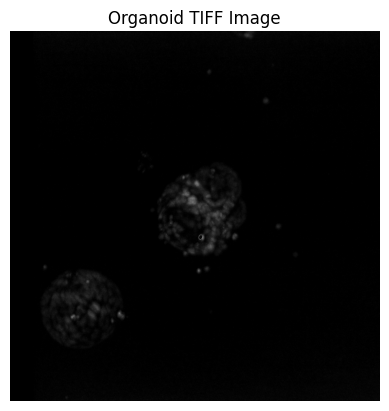

In [62]:
plt.imshow(image)
plt.axis("off")
plt.title("Organoid TIFF Image")
plt.show()

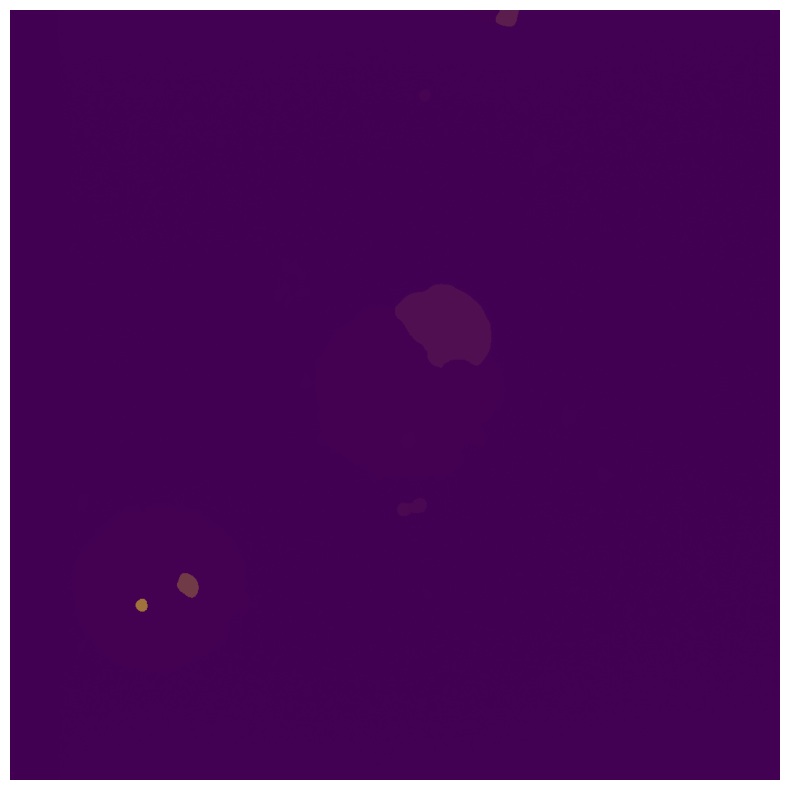

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(image)
for mask in bright_masks:
    plt.imshow(mask["segmentation"], alpha=0.5)
plt.axis("off")
plt.show()

In [79]:
import napari

viewer = napari.Viewer()
viewer.add_image(image, name="image", blending="additive", colormap="gray")
viewer.add_labels(
    np.array([mask["segmentation"] for mask in bright_masks]))

napari.run()

In [81]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30 / 255, 144 / 255, 255 / 255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels == 1]
    neg_points = coords[labels == 0]
    ax.scatter(
        pos_points[:, 0],
        pos_points[:, 1],
        color="green",
        marker="*",
        s=marker_size,
        edgecolor="white",
        linewidth=1.25,
    )
    ax.scatter(
        neg_points[:, 0],
        neg_points[:, 1],
        color="red",
        marker="*",
        s=marker_size,
        edgecolor="white",
        linewidth=1.25,
    )


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(
        plt.Rectangle((x0, y0), w, h, edgecolor="green", facecolor=(0, 0, 0, 0), lw=2)
    )

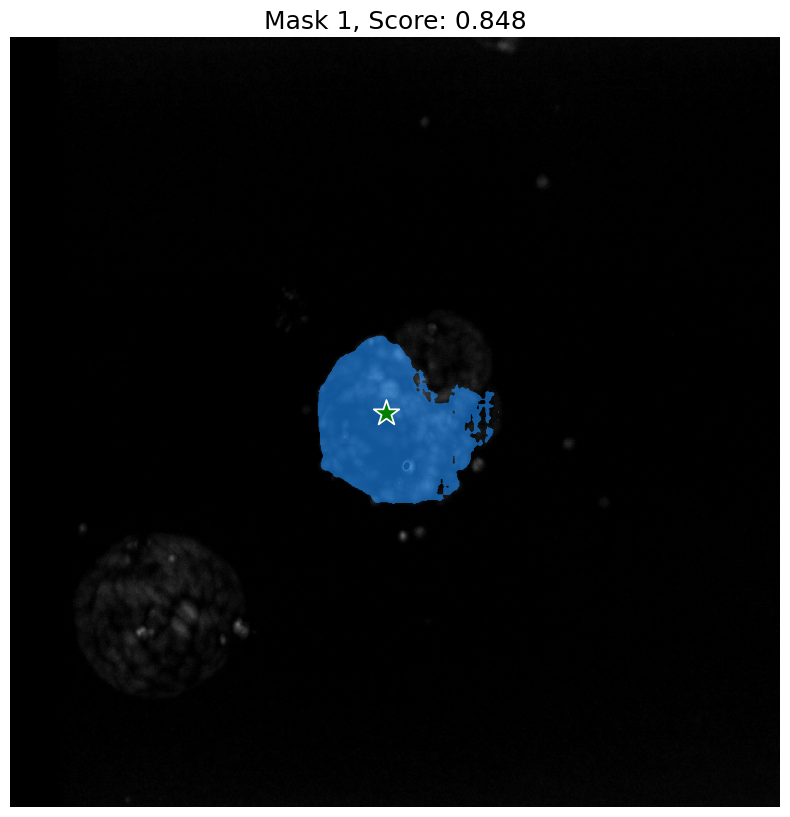

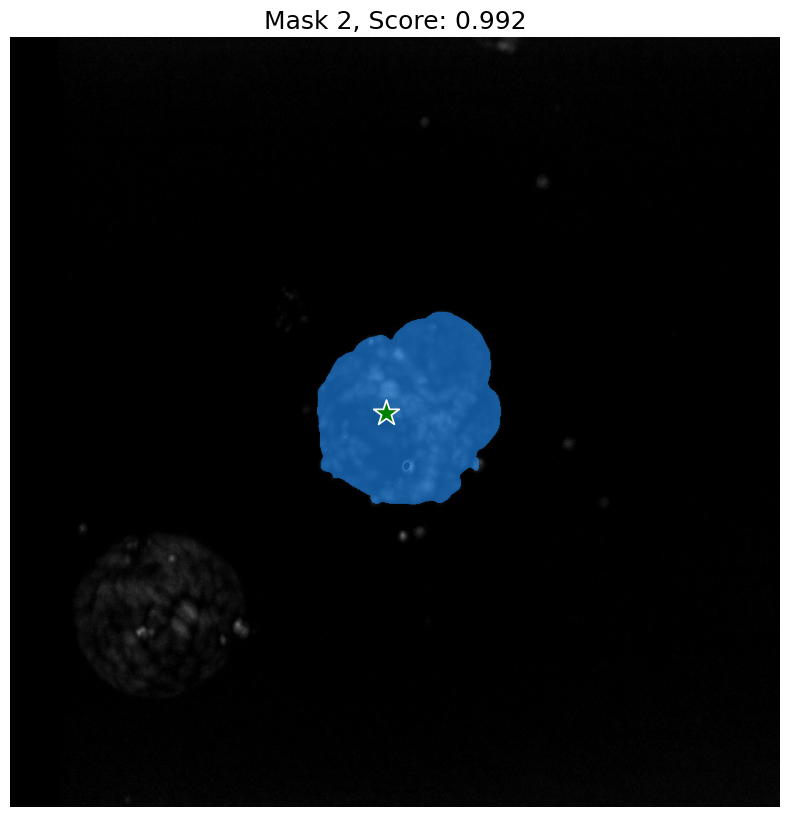

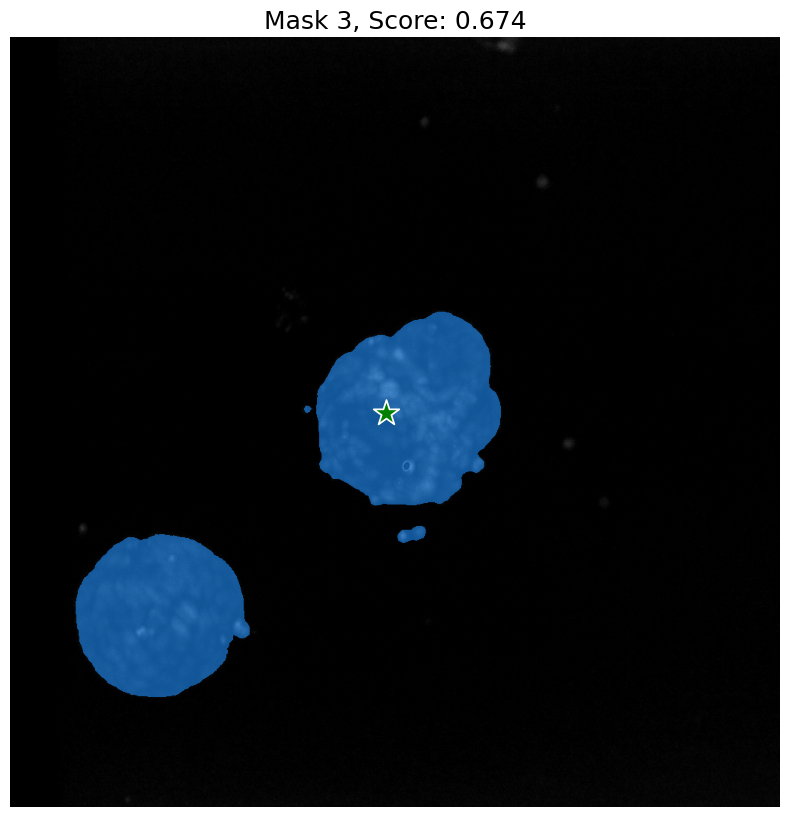

In [84]:
input_point = np.array([
    [500, 500]
])  # Example coordinates input_label = [1] # Positive point predictor.set_image(image)
input_label = np.array([1])  # Positive point
predictor.set_image(image)
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)


for i, (mask, score) in enumerate(zip(masks, scores)):
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    show_mask(mask, plt.gca())
    show_points(input_point, input_label, plt.gca())
    plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
    plt.axis("off")
    plt.show()

In [30]:
import torch
from sam2.build_sam import build_sam2_video_predictor

# CHECKPOINT = r"C:\Users\6331823\Downloads\sam2.1_hiera_base_plus.pt"
# CONFIG = r"C:\Users\6331823\Downloads\sam2.1_hiera_b+.yaml"
CHECKPOINT = r"C:\Users\6331823\Downloads\sam2.1_hiera_small.pt"
CONFIG = r"C:\Users\6331823\Downloads\sam2.1_hiera_s.yaml"

sam2_model = build_sam2_video_predictor(CONFIG, CHECKPOINT)

In [4]:
import supervision as sv
video_path = r"C:\Users\6331823\Downloads\EXpansionLMix_3_projXY.avi"
frame_path = r"C:\Users\6331823\Downloads\test"
target_video_path = r"C:\Users\6331823\Downloads\test_output.avi"

frames_generator = sv.get_video_frames_generator(video_path)

sink = sv.ImageSink(
    target_dir_path= frame_path,
    image_name_pattern="{:05d}.jpeg")

with sink:
    for frame in frames_generator:
        sink.save_image(frame)

inference_state = sam2_model.init_state(frame_path)

frame loading (JPEG): 100%|██████████| 15/15 [00:00<00:00, 44.63it/s]


In [20]:
import numpy as np

points = np.array([[500, 500]], dtype=np.float32)
labels = np.array([1])
frame_idx = 0
tracker_id = 1

_, object_ids, mask_logits = sam2_model.add_new_points(
    inference_state=inference_state,
    frame_idx=frame_idx,
    obj_id=tracker_id,
    points=points,
    labels=labels,
)


Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).


In [5]:
import cv2
import supervision as sv

colors = ['#FF1493', '#00BFFF', '#FF6347', '#FFD700']
mask_annotator = sv.MaskAnnotator(
    color=sv.ColorPalette.from_hex(colors),
    color_lookup=sv.ColorLookup.TRACK)

video_info = sv.VideoInfo.from_video_path(video_path)
frames_paths = sorted(sv.list_files_with_extensions(
    directory=frame_path, 
    extensions=["jpeg"]))

all_masks = []

with sv.VideoSink(target_video_path, video_info=video_info) as sink:
    for frame_idx, object_ids, mask_logits in sam2_model.propagate_in_video(inference_state):
        frame = cv2.imread(frames_paths[frame_idx])
        masks = (mask_logits > 0.0).cpu().numpy()
        N, X, H, W = masks.shape
        masks = masks.reshape(N * X, H, W)
        all_masks.append(masks)
        detections = sv.Detections(
            xyxy=sv.mask_to_xyxy(masks=masks),
            mask=masks,
            tracker_id=np.array(object_ids)
        )
        frame = mask_annotator.annotate(frame, detections)
        sink.write_frame(frame)

RuntimeError: No input points or masks are provided for any object; please add inputs first.

In [14]:
import os, shutil, tempfile
import numpy as np
from PIL import Image
from scipy.ndimage import binary_dilation
import napari

viewer = napari.Viewer()
input_directory = r"C:\Users\6331823\Local SSD\Data_Anna\mixed"
movies = []

for folder in os.scandir(input_directory):
    if folder.is_dir():
        file = [file for file in os.listdir(folder.path) if file.endswith("projXY.tif")][0]
        movies.append(os.path.join(folder.path, file))

movies = [
    r"C:\\Users\\6331823\\Local SSD\\Data_Anna\\mixed\\EXpansionLMix_11\\EXpansionLMix_11_projXY.tif"
]

for movie_path in movies:
    movie = tifffile.imread(movie_path)
    movie = ((movie / movie.max()) * 255).astype(np.uint8)

    # Temporary directory for saving frames
    temp_dir = tempfile.mkdtemp()

    # Itterate over movie frames
    for i, frame in enumerate(movie):
        # Convert image to RGB grayscale image
        if frame.ndim == 2: 
            frame = np.stack([frame] * 3, axis=-1)

        # Normalize the frame to 0-255 range
        frame = (frame / frame.max() * 255).astype(np.uint8)

        # Save the frame as a JPEG image
        Image.fromarray(frame).save(os.path.join(temp_dir, f"{i:05d}.jpeg"))

    # Get inference state
    inference_state = sam2_model.init_state(temp_dir)

    # Calculate center point where organoid should be
    # center_point = np.array([[movie.shape[1] // 2, movie.shape[2] // 2]], dtype=np.float32)
    center_point = get_center(movie)
    _, object_ids, mask_logits = sam2_model.add_new_points(
        inference_state=inference_state,
        frame_idx=0,
        obj_id=1,
        points=center_point,
        labels=np.array([1]),
    )

    all_masks = []

    for frame_idx, object_ids, mask_logits in sam2_model.propagate_in_video(
        inference_state
    ):
        masks = (mask_logits > 0.0).cpu().numpy()  # shape: (N, X, H, W)
        N, X, H, W = masks.shape
        masks = masks.reshape(N * X, H, W)
        all_masks.append(masks)

    shutil.rmtree(temp_dir)

    all_masks = np.stack(all_masks, axis=0)  # shape: (T, N, H, W)
    all_masks = all_masks[:, 0]

    timepoints = movie.shape[0]
    new_masks = []
    for frame in range(timepoints):
        mask = all_masks[frame]
        mask = binary_dilation(mask, iterations=12)
        new_masks.append(mask)

    new_masks = np.stack(new_masks, axis=0).astype(np.uint16)

    # Make a movie that only shows the original movie at the place of the selected organoid
    organoid_only = np.where(new_masks, movie, 0)

    viewer.add_image(movie, name=f"{os.path.basename(movie_path)} image", blending="additive", colormap="gray", visible=False)
    viewer.add_image(
        organoid_only,
        name=f"{os.path.basename(movie_path)} tracked",
        blending="additive",
        colormap="gray",
        visible=False,
    )
    viewer.add_labels(
        new_masks, name=f"{os.path.basename(movie_path)} masks", blending="additive", visible=False
    )

frame loading (JPEG): 100%|██████████| 15/15 [00:00<00:00, 49.82it/s]
C:\Users\6331823\segment-anything-2\sam2\sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (C:\Users\6331823\segment-anything-2\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 15/15 [00:00<00:00, 15.24it/s]


In [3]:
import scipy.ndimage as ndimage
import pandas as pd
import cv2

def get_center(movie):
    first_frame = movie[0]
    # Normalize and convert to 8-bit
    frame = ((first_frame / first_frame.max()) * 255).astype(np.uint8)
    frame = ndimage.gaussian_filter(frame, sigma=(10, 10))

    # Apply threshold (you can tweak the value)
    median = np.median(frame)
    mean = np.mean(frame)
    _, binary_mask = cv2.threshold(frame, median+10, 255, cv2.THRESH_BINARY)

    filled_mask = ndimage.binary_fill_holes(binary_mask).astype(np.uint8)
    num_labels, labels, stats_array, centroids = cv2.connectedComponentsWithStats(
        filled_mask
    )
    center = np.array([frame.shape[0] // 2, frame.shape[1] // 2])

    df = {
        "label": np.arange(1, num_labels),
        "area": stats_array[1:, cv2.CC_STAT_AREA],
        "centroid": [c for c in centroids[1:]],  # keep as array
    }

    df = pd.DataFrame(df)
    # Compute distances to center
    df["distance_to_center"] = df["centroid"].apply(lambda c: np.linalg.norm(center - c))

    # Filter and select
    filtered_df = df[df["area"] > 3000]
    closest = filtered_df.loc[filtered_df["distance_to_center"].idxmin()]

    # Result
    selected_centroid = closest["centroid"]
    selected_centroid = np.array([[selected_centroid[0], selected_centroid[1]]], dtype=np.float32)
    return(selected_centroid)

In [11]:
import napari
movie = tifffile.imread(
    r"C:\\Users\\6331823\\Local SSD\\Data_Anna\\mixed\\EXpansionLMix_3\\EXpansionLMix_3.tif"
)
nuclei = movie[:,:,2,:,:]
proj_XZ = np.max(nuclei, axis=2)

viewer = napari.Viewer()
viewer.add_image(
    proj_XZ,
    name=f"xz",
    blending="additive",
    colormap="gray",
)

<Image layer 'xz' at 0x1878587b410>

In [9]:
from PIL import Image
from scipy.ndimage import binary_dilation

movie = tifffile.imread(
    r"C:\\Users\\6331823\\Local SSD\\Data_Anna\\mixed\\EXpansionLMix_3\\EXpansionLMix_3.tif"
)

proj_XY = tifffile.imread(
    r"C:\\Users\\6331823\\Local SSD\\Data_Anna\\mixed\\EXpansionLMix_3\\EXpansionLMix_3_projXY.tif"
)
proj_XY_8bit = ((proj_XY / proj_XY.max()) * 255).astype(np.uint8)

# Temporary directory for saving frames
temp_dir = tempfile.mkdtemp()

# Itterate over proj_XY_8bit frames
for i, frame in enumerate(proj_XY_8bit):
    # Convert image to RGB grayscale image
    if frame.ndim == 2: 
        frame = np.stack([frame] * 3, axis=-1)

    # Normalize the frame to 0-255 range
    frame = (frame / frame.max() * 255).astype(np.uint8)

    # Save the frame as a JPEG image
    Image.fromarray(frame).save(os.path.join(temp_dir, f"{i:05d}.jpeg"))

# Get inference state
inference_state = sam2_model.init_state(temp_dir)

# Calculate center point where organoid should be
# center_point = np.array([[proj_XY_8bit.shape[1] // 2, proj_XY_8bit.shape[2] // 2]], dtype=np.float32)
center_point = get_center(proj_XY_8bit)
_, object_ids, mask_logits = sam2_model.add_new_points(
    inference_state=inference_state,
    frame_idx=0,
    obj_id=1,
    points=center_point,
    labels=np.array([1]),
)

all_masks = []

for frame_idx, object_ids, mask_logits in sam2_model.propagate_in_video(
    inference_state
):
    masks = (mask_logits > 0.0).cpu().numpy()  # shape: (N, X, H, W)
    N, X, H, W = masks.shape
    masks = masks.reshape(N * X, H, W)
    all_masks.append(masks)

shutil.rmtree(temp_dir)

all_masks = np.stack(all_masks, axis=0)  # shape: (T, N, H, W)
all_masks = all_masks[:, 0]

timepoints = proj_XY_8bit.shape[0]
new_masks = []
for frame in range(timepoints):
    mask = all_masks[frame]
    mask = binary_dilation(mask, iterations=12)
    new_masks.append(mask)

new_masks = np.stack(new_masks, axis=0).astype(np.uint16)

# Make a proj_XY_8bit that only shows the original proj_XY_8bit at the place of the selected organoid
organoid_only = np.where(new_masks, proj_XY, 0)

frame loading (JPEG): 100%|██████████| 15/15 [00:00<00:00, 42.47it/s]
C:\Users\6331823\segment-anything-2\sam2\sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (C:\Users\6331823\segment-anything-2\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 15/15 [00:00<00:00, 15.31it/s]


In [13]:
import napari
timepoints, y , x = proj_XY.shape

cropped = []
max_dims = [0, 0, 0]
for frame in range(timepoints):
    # Find the XY coordinates of the mask
    maskXY = organoid_only[frame] > 0
    coordsXY = np.where(maskXY)

    # Adjust cropping limits based on XY projection, creating a bounding box around the organoid
    if coordsXY[0].size > 0:
        row_min, row_max = (
            np.min(coordsXY[0]),
            np.max(coordsXY[0]) + 1,
        )
        col_min, col_max = (
            np.min(coordsXY[1]),
            np.max(coordsXY[1]) + 1,
        )

    # Get the frame of the movie
    ref = movie[frame, :, 2, row_min:row_max, col_min:col_max]
    for i in range(3):
        max_dims[i] = max(max_dims[i], ref.shape[i])
    

    # Get a bounding box cropped version of the organoid
    ref_crop = maskXY[row_min:row_max, col_min:col_max]

    ref_expanded = ref_crop[np.newaxis, :, :] 
    ref_expanded = np.repeat(ref_expanded, ref.shape[0], axis=0) # expand over Z
    ref_masked = np.where(ref_expanded > 0, ref, 0).astype(np.uint16)
    cropped.append(ref_masked)

    XZ = np.max(ref_masked, axis=1)

    # Use the this XYZ mask on the original movie to crop as both a bounding box and to make all pixels (corners) where there is no organoid actually black
    ref_masked = np.where(ref_expanded > 0, ref, 0).astype(np.uint16)

cropped = [
    pad_to_shape(stack, max_dims) for stack in cropped
]
cropped = np.stack(cropped, axis = 0)
viewer = napari.Viewer()
viewer.add_image(
    cropped,
    name=f"xz",
    blending="additive",
    colormap="gray",
)

<Image layer 'xz' at 0x2712e38ead0>

In [18]:
proj_XZ = np.max(cropped, axis = 2)
viewer = napari.Viewer()
viewer.add_image(
    proj_XZ,
    name=f"xz",
    blending="additive",
    colormap="gray",
    scale = (6,1),
)
viewer.add_image(
    movie,
    name=f"movie",
    blending="additive",
    colormap="gray",
)

<Image layer 'movie' at 0x27127ebfc50>

In [11]:
def pad_to_shape(array, target_shape):
    pad_width = []
    for dim, target in zip(array.shape, target_shape):
        total_pad = target - dim
        pad_before = total_pad // 2
        pad_after = total_pad - pad_before
        pad_width.append((pad_before, pad_after))
    return np.pad(array, pad_width, mode="constant", constant_values=0)

In [60]:
first_frame = proj_XZ[0]

# Normalize and convert to 8-bit
frame = ((first_frame / first_frame.max()) * 255).astype(np.uint8)
# frame = ndimage.gaussian_filter(frame, sigma=(10, 10))

# Apply threshold (you can tweak the value)
# Flatten the frame and filter out zeros
nonzero_pixels = first_frame[first_frame > 0]

# Compute the median
median = np.median(nonzero_pixels)


_, binary_mask = cv2.threshold(frame, median-30, 255, cv2.THRESH_BINARY)

filled_mask = ndimage.binary_fill_holes(binary_mask).astype(np.uint8)
num_labels, labels, stats_array, centroids = cv2.connectedComponentsWithStats(
    binary_mask
)

df = {
    "label": np.arange(1, num_labels),
    "area": stats_array[1:, cv2.CC_STAT_AREA],
    "centroid": [c for c in centroids[1:]],  # keep as array
}

df = pd.DataFrame(df)
biggest = df.loc[df["area"].idxmax()]
print(df)
# # Result
selected_centroid = biggest["centroid"]
selected_centroid = np.array([[selected_centroid[0], selected_centroid[1]]], dtype=np.float32)
print(selected_centroid)

viewer = napari.Viewer()
viewer.add_image(
    frame,
    name=f"xz",
    blending="additive",
    colormap="gray",
    scale=(6, 1),
)
viewer.add_image(
    binary_mask,
    name=f"xz",
    blending="additive",
    colormap="gray",
    scale=(1, 1),
)

    label  area                                  centroid
0       1    14  [362.07142857142856, 26.357142857142858]
1       2     1                             [369.0, 27.0]
2       3  1353    [473.6718403547672, 29.76570583887657]
3       4     1                             [552.0, 26.0]
4       5     1                             [565.0, 27.0]
5       6     1                             [569.0, 27.0]
6       7     1                             [367.0, 29.0]
7       8    14               [358.0, 30.357142857142858]
8       9     4                             [397.5, 31.0]
9      10    15  [402.46666666666664, 32.733333333333334]
10     11     6               [357.5, 35.333333333333336]
11     12     9    [368.3333333333333, 34.44444444444444]
12     13     2                             [394.5, 34.0]
13     14     1                             [522.0, 34.0]
14     15     2                             [447.5, 41.0]
[[473.67184   29.765705]]


<Image layer 'xz [1]' at 0x271f2c21c90>

In [67]:
proj_XZ_8bit = ((proj_XZ / proj_XZ.max()) * 255).astype(np.uint8)
median = np.median(proj_XZ_8bit[proj_XZ_8bit > 0])
proj_XZ_8bit[proj_XZ_8bit < median] = 0

# Temporary directory for saving frames
temp_dir = tempfile.mkdtemp()

# Itterate over proj_XZ_8bit frames
for i, frame in enumerate(proj_XZ_8bit):
    # Convert image to RGB grayscale image
    if frame.ndim == 2:
        frame = np.stack([frame] * 3, axis=-1)

    # Normalize the frame to 0-255 range
    frame = (frame / frame.max() * 255).astype(np.uint8)

    # Save the frame as a JPEG image
    Image.fromarray(frame).save(os.path.join(temp_dir, f"{i:05d}.jpeg"))

# Get inference state
inference_state = sam2_model.init_state(temp_dir)

# Calculate center point where organoid should be
center_point = selected_centroid
_, object_ids, mask_logits = sam2_model.add_new_points(
    inference_state=inference_state,
    frame_idx=0,
    obj_id=1,
    points=center_point,
    labels=np.array([1]),
)

all_masks = []

for frame_idx, object_ids, mask_logits in sam2_model.propagate_in_video(
    inference_state
):
    masks = (mask_logits > 0.0).cpu().numpy()  # shape: (N, X, H, W)
    N, X, H, W = masks.shape
    masks = masks.reshape(N * X, H, W)
    all_masks.append(masks)

shutil.rmtree(temp_dir)

all_masks = np.stack(all_masks, axis=0)  # shape: (T, N, H, W)
all_masks = all_masks[:, 0]

timepoints = proj_XZ_8bit.shape[0]
new_masks = []
for frame in range(timepoints):
    mask = all_masks[frame]
    mask = binary_dilation(mask, iterations=1)
    new_masks.append(mask)

new_masks = np.stack(new_masks, axis=0).astype(np.uint16)
organoid_only = np.where(new_masks, proj_XZ, 0)

viewer = napari.Viewer()
viewer.add_image(proj_XZ_8bit, name= "image", blending="additive", colormap="gray", visible=False, scale=(6,1))
viewer.add_image(
    organoid_only,
    name=f" tracked",
    blending="additive",
    colormap="gray",
    visible=False, scale=(6,1)
)
viewer.add_labels(
    new_masks, name="masks", blending="additive", visible=False, scale=(6, 1)
)

frame loading (JPEG): 100%|██████████| 15/15 [00:00<00:00, 50.64it/s]
C:\Users\6331823\segment-anything-2\sam2\sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (C:\Users\6331823\segment-anything-2\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 15/15 [00:00<00:00, 15.34it/s]


<Labels layer 'masks' at 0x271e67e9ed0>

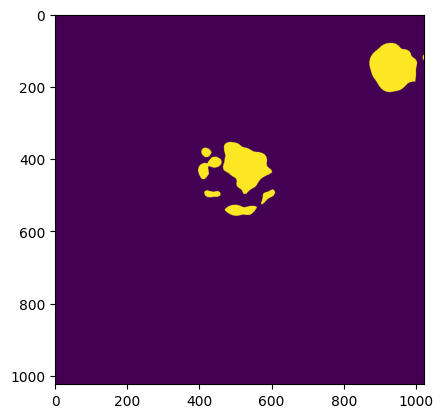

In [4]:
from scipy import ndimage
import cv2
proj_XY = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Anna\Exp139\EXpansion_CRC_1\EXpansion_CRC_1_projXY.tif"
)
first_frame = proj_XY[0]
# Normalize and convert to 8-bit
frame = ((first_frame / first_frame.max()) * 255).astype(np.uint8)
frame = ndimage.gaussian_filter(frame, sigma=(10, 10))

# Apply threshold (you can tweak the value)
median = np.median(frame)
mean = np.mean(frame)
_, binary_mask = cv2.threshold(frame, median + 10, 255, cv2.THRESH_BINARY)

filled_mask = ndimage.binary_fill_holes(binary_mask).astype(np.uint8)

plt.imshow(filled_mask)
# plt.imshow(first_frame)

def get_center(movie):
    first_frame = movie[0]
    # Normalize and convert to 8-bit
    frame = ((first_frame / first_frame.max()) * 255).astype(np.uint8)
    frame = ndimage.gaussian_filter(frame, sigma=(10, 10))

    # Apply threshold (you can tweak the value)
    median = np.median(frame)
    mean = np.mean(frame)
    _, binary_mask = cv2.threshold(frame, median + 0, 255, cv2.THRESH_BINARY)

    binary_mask = ndimage.binary_dilation(binary_mask, iterations=5)
    filled_mask = ndimage.binary_fill_holes(binary_mask).astype(np.uint8)
    num_labels, labels, stats_array, centroids = cv2.connectedComponentsWithStats(
        filled_mask
    )
    center = np.array([frame.shape[0] // 2, frame.shape[1] // 2])

    df = {
        "label": np.arange(1, num_labels),
        "area": stats_array[1:, cv2.CC_STAT_AREA],
        "centroid": [c for c in centroids[1:]],  # keep as array
    }

    df = pd.DataFrame(df)
    # Compute distances to center
    df["distance_to_center"] = df["centroid"].apply(
        lambda c: np.linalg.norm(center - c)
    )

    # Filter and select
    filtered_df = df[df["area"] > 3000]
    closest = filtered_df.loc[filtered_df["distance_to_center"].idxmin()]

    # Result
    selected_centroid = closest["centroid"]
    selected_centroid = np.array(
        [[selected_centroid[0], selected_centroid[1]]], dtype=np.float32
    )
    return selected_centroid

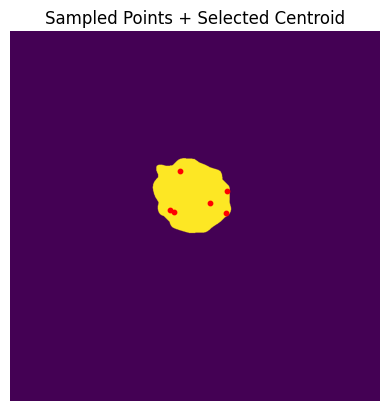

In [36]:
import pandas as pd
proj_XY = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Anna\Exp139\EXpansion_CRC_1\EXpansion_CRC_1_projXY.tif"
)
first_frame = proj_XY[0]
# plt.imshow(first_frame, cmap='gray')
# Normalize and convert to 8-bit
frame = ((first_frame / first_frame.max()) * 255).astype(np.uint8)
frame = ndimage.gaussian_filter(frame, sigma=(10, 10))

# Apply threshold (you can tweak the value)
median = np.median(frame)
_, binary_mask = cv2.threshold(frame, median + 5, 255, cv2.THRESH_BINARY)

binary_mask = ndimage.binary_dilation(binary_mask, iterations=10)
filled_mask = ndimage.binary_fill_holes(binary_mask).astype(np.uint8)

# plt.imshow(filled_mask)
num_labels, labels, stats_array, centroids = cv2.connectedComponentsWithStats(
    filled_mask
)
center = np.array([frame.shape[0] // 2, frame.shape[1] // 2])

df = {
    "label": np.arange(1, num_labels),
    "area": stats_array[1:, cv2.CC_STAT_AREA],
    "centroid": [c for c in centroids[1:]],  # keep as array
}

df = pd.DataFrame(df)
# Compute distances to center
df["distance_to_center"] = df["centroid"].apply(
    lambda c: np.linalg.norm(center - c)
)

# Filter and select
filtered_df = df[df["area"] > 3000]
closest = filtered_df.loc[filtered_df["distance_to_center"].idxmin()]
selected_label = closest["label"]


labels = labels == selected_label
labels = ndimage.binary_erosion(labels, iterations=15)
plt.imshow(labels)

coords = np.column_stack(np.nonzero(labels))


sampled_points = coords[np.random.choice(len(coords), 5, replace=False)]
selected_centroid = closest["centroid"]
selected_centroid = np.array(
    [[int(selected_centroid[0]), int(selected_centroid[1])]], dtype=np.int32
)

combined_points = np.vstack([sampled_points, selected_centroid])
plt.scatter(combined_points[:, 1], combined_points[:, 0], c="red", s=10)

plt.title("Sampled Points + Selected Centroid")
plt.axis("off")
plt.show()

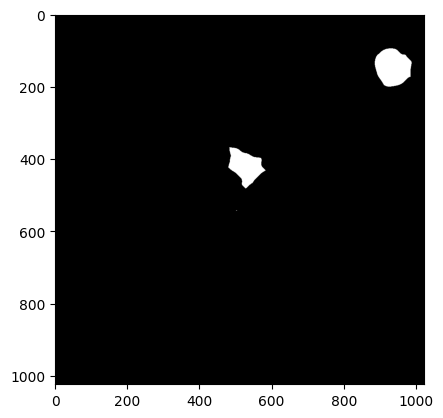

In [9]:
big_mask = ndimage.binary_erosion(filled_mask, iterations=15)
big_mask = ndimage.binary_fill_holes(big_mask).astype(np.uint8)
plt.imshow(big_mask, cmap = "gray")

In [109]:
def get_centers(movie):
    first_frame = movie[0]
    # Normalize and convert to 8-bit
    frame = ((first_frame / first_frame.max()) * 255).astype(np.uint8)
    frame = ndimage.gaussian_filter(frame, sigma=(10, 10))

    # Apply threshold (you can tweak the value)
    median = np.median(frame)
    _, binary_mask = cv2.threshold(frame, median + 10, 255, cv2.THRESH_BINARY)

    binary_mask = ndimage.binary_dilation(binary_mask, iterations=5)
    filled_mask = ndimage.binary_fill_holes(binary_mask).astype(np.uint8)
    num_labels, labels, stats_array, centroids = cv2.connectedComponentsWithStats(
        filled_mask
    )
    
    center = np.array([frame.shape[0] // 2, frame.shape[1] // 2])

    df = {
        "label": np.arange(1, num_labels),
        "area": stats_array[1:, cv2.CC_STAT_AREA],
        "centroid": [c for c in centroids[1:]],  # keep as array
    }

    df = pd.DataFrame(df)
    # Compute distances to center
    df["distance_to_center"] = df["centroid"].apply(
        lambda c: np.linalg.norm(center - c)
    )

    # Filter and select
    filtered_df = df[df["area"] > 3000]
    closest = filtered_df.loc[filtered_df["distance_to_center"].idxmin()]
    selected_label = closest["label"]

    # Create a binary mask for the selected label
    selected_mask = (labels == selected_label).astype(np.uint8)

    # Apply erosion only to that mask
    eroded_mask = ndimage.binary_erosion(selected_mask, iterations=15)

    # Get coordinates from the eroded mask
    coords = np.column_stack(np.where(eroded_mask))

    sampled_points = coords[np.random.choice(len(coords), 5, replace=False)]
    selected_centroid = closest["centroid"]
    selected_centroid = np.array(
        [[int(selected_centroid[0]), int(selected_centroid[1])]], dtype=np.int32
    )

    combined_points = np.vstack([sampled_points, selected_centroid])

    return combined_points

In [110]:
from PIL import Image
from scipy.ndimage import binary_dilation

proj_XY = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\Mix_s48\Mix_s48_projXY.tif"
)
proj_XY_8bit = ((proj_XY / proj_XY.max()) * 255).astype(np.uint8)

# Temporary directory for saving frames
temp_dir = tempfile.mkdtemp()

# Itterate over proj_XY_8bit frames
for i, frame in enumerate(proj_XY_8bit):
    # Convert image to RGB grayscale image
    if frame.ndim == 2:
        frame = np.stack([frame] * 3, axis=-1)

    # Normalize the frame to 0-255 range
    frame = (frame / frame.max() * 255).astype(np.uint8)

    # Save the frame as a JPEG image
    Image.fromarray(frame).save(os.path.join(temp_dir, f"{i:05d}.jpeg"))

# Get inference state
inference_state = sam2_model.init_state(temp_dir)

# Calculate center point where organoid should be
# center_point = np.array([[proj_XY_8bit.shape[1] // 2, proj_XY_8bit.shape[2] // 2]], dtype=np.float32)
center_point = get_centers(proj_XY_8bit)
_, object_ids, mask_logits = sam2_model.add_new_points(
    inference_state=inference_state,
    frame_idx=0,
    obj_id=1,
    points=center_point,
    labels=np.ones(len(center_point)),
)

all_masks = []

for frame_idx, object_ids, mask_logits in sam2_model.propagate_in_video(
    inference_state
):
    masks = (mask_logits > 0.0).cpu().numpy()  # shape: (N, X, H, W)
    N, X, H, W = masks.shape
    masks = masks.reshape(N * X, H, W)
    all_masks.append(masks)

shutil.rmtree(temp_dir)

all_masks = np.stack(all_masks, axis=0)  # shape: (T, N, H, W)
all_masks = all_masks[:, 0]

timepoints = proj_XY_8bit.shape[0]
new_masks = []
for frame in range(timepoints):
    mask = all_masks[frame]
    mask = binary_dilation(mask, iterations=12)
    new_masks.append(mask)

new_masks = np.stack(new_masks, axis=0).astype(np.uint16)

# Make a proj_XY_8bit that only shows the original proj_XY_8bit at the place of the selected organoid
organoid_only = np.where(new_masks, proj_XY, 0)

viewer = napari.Viewer()
viewer.add_image(proj_XY, blending="additive")
viewer.add_image(new_masks, blending="additive")

frame loading (JPEG): 100%|██████████| 14/14 [00:00<00:00, 52.76it/s]
C:\Users\6331823\segment-anything-2\sam2\sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (C:\Users\6331823\segment-anything-2\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 14/14 [00:00<00:00, 15.55it/s]


<Image layer 'new_masks' at 0x198feda0810>

In [116]:
import napari

movie = tifffile.imread(
    r"C:\Users\6331823\Local SSD\Data_Anna\Exp137\CRC_s41\segmented_movie.tif"
)
print(movie.shape)
viewer = napari.Viewer()
viewer.add_labels(data = movie, name="segmented", scale=(1,8,1,1))

(14, 54, 390, 389)


<Labels layer 'segmented' at 0x199ba377590>